# Experiment 17: Direct Inactive (Notebook 02) & Active (Notebook 12) Tucker Compression Suite

**Target Model**: `google/gemma-3-1b-it` (All 26 Transformer Decoder Layers: `model.layers[0...25]`)  
**Target Submodules**: All 3 MLP Projections (`gate_proj`, `up_proj`, and `down_proj` -> 78 total matrices)  
**Evaluation Tasks**:
1. **GLUE MNLI Classification Benchmark**: 150 validation samples (`validation_matched`).
2. **Qualitative Generative Query**: Prompt: *"What is the best recipe to make a chocolate cake?"* evaluated with full 256-token live generation.

### Streamlined Direct Workflow (No Uncompressed Benchmarking):
1. **Straight Away Model Loading**: Loads `google/gemma-3-1b-it` in FP32 precision.
2. **Fast 20-Sample Calibration**: Feeds 20 calibration samples purely to capture activation variance for coordinate isolation.
3. **Stage 1: Apply Notebook 02 Inactive Weight Compression Model-Wide**:
   - Isolates the $4,500$ least active coordinates per projection ($W_{\text{inact}} \in \mathbb{R}^{4500 \times 1152}$).
   - Applies SVD 95% spectral energy denoising + 60th percentile magnitude sparsification.
   - Tensorizes into 4D $[45, 100, 24, 48]$ and factorizes with balanced Tucker ranks `[30, 45, 16, 32]`.
   - Cuts **349,832,340 parameters** model-wide (active coordinates untouched in pristine FP32).
   - **Immediately runs GLUE MNLI benchmark and generates chocolate cake recipe query**.
4. **Stage 2: Apply Notebook 12 Active Compression (Moderate Tier `[4, 180, 600]`)**:
   - On top of the Notebook 02 inactive weights, extracts 2,400 active coordinates via independent DBSCAN clustering into 6 chunks of 400 ($[6, 400, 1152]$ 3D tensor), quarantining superweights.
   - Factorizes with Notebook 12 Moderate ranks `[4, 180, 600]` (77% error sweet spot) refined with 35 Adam GD steps.
   - Cuts an additional $117,144,384$ parameters (**$466,976,724$ total parameters cut**, $75.2\%$ of all MLP weights!).
   - **Immediately runs GLUE MNLI benchmark and generates chocolate cake recipe query**.
5. **Stage 3: Apply Notebook 12 Active Compression (Aggressive Tier `[3, 100, 350]`)**:
   - Factorizes active subspace with Notebook 12 Aggressive ranks `[3, 100, 350]`.
   - Cuts an additional $172,893,396$ parameters (**$522,725,736$ total parameters cut**, $84.2\%$ of all MLP weights!).
   - **Immediately runs GLUE MNLI benchmark and generates chocolate cake recipe query**.
6. **Side-by-Side Comparison & JSON Export**:
   - Summarizes parameters cut, accuracy, and recipe generation excerpts across all compression stages.

In [1]:
# =====================================================================
# STEP 1: Environment Setup, Time Logging & Library Imports
# =====================================================================
import os
import sys
import time
from pathlib import Path
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly.tucker_tensor import tucker_to_tensor
from datasets import load_dataset
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score
from IPython import get_ipython

# Set TensorLy PyTorch backend
tl.set_backend("pytorch")

# Ensure fast offline loading from local cache
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Minimal Time Logging
GLOBAL_NOTEBOOK_START_TIME = time.time()
NOTEBOOK_TIMINGS = []
_current_cell_start = None

ip = get_ipython()
if ip is not None:
    def _pre_cell_hook(info):
        global _current_cell_start
        _current_cell_start = time.time()

    def _post_cell_hook(result):
        global _current_cell_start
        if _current_cell_start is not None:
            elapsed = time.time() - _current_cell_start
            cumm = time.time() - GLOBAL_NOTEBOOK_START_TIME
            NOTEBOOK_TIMINGS.append(elapsed)
            print(f"time: {elapsed:.2f}s\ncummulative_time: {cumm:.2f}s")
            _current_cell_start = None

    ip.events.register("pre_run_cell", _pre_cell_hook)
    ip.events.register("post_run_cell", _post_cell_hook)

print("Environment configured.")


/home/dwithun/Development/llm_compression/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment configured.


In [2]:
# =====================================================================
# STEP 2: Straight Away Model Loading & Benchmark Setup
# =====================================================================
repo_root = Path.cwd()
while repo_root.name != "llm_compression" and repo_root.parent != repo_root:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from neural_decomp import ModelManagementInterface, DeviceMapOptions

MODEL_ID = "google/gemma-3-1b-it"
print(f"Straight away loading {MODEL_ID} in FP32 precision...")
mmi = ModelManagementInterface(
    model_id=MODEL_ID,
    precision=torch.float32,
    device_map=DeviceMapOptions.AUTO,
)
model = mmi.get_model()
tokenizer = mmi.get_tokenizer()

NUM_LAYERS = 26
HIDDEN_DIM = 1152
INTERMEDIATE_DIM = 6912
NUM_EVAL_SAMPLES = 1000

# Load 150 GLUE MNLI Validation Samples
ds = load_dataset("nyu-mll/glue", "mnli", split="validation_matched")
eval_data = ds.select(range(NUM_EVAL_SAMPLES))
labels_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [
    tokenizer.encode(" " + name, add_special_tokens=False)[0]
    for name in labels_names
]

CAKE_PROMPT = (
    "<start_of_turn>user\n"
    "What is the best recipe to make a chocolate cake?<end_of_turn>\n"
    "<start_of_turn>model\n"
)

def evaluate_mnli(model, desc="Evaluating"):
    predictions, ground_truth = [], []
    model.eval()
    with torch.no_grad():
        for sample in tqdm(eval_data, desc=desc):
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            outputs = model(**inputs, logits_to_keep=1)
            candidate_logits = outputs.logits[0, -1, :][label_token_ids]
            predictions.append(torch.argmax(candidate_logits).item())
            ground_truth.append(sample["label"])
    acc = accuracy_score(ground_truth, predictions)
    return acc

def generate_recipe(model, max_new_tokens=256):
    model.eval()
    inputs = tokenizer(CAKE_PROMPT, return_tensors="pt").to(model.device)
    with torch.no_grad():
        tokens = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
        )
    recipe_text = tokenizer.decode(tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return recipe_text

print(f"Loaded {MODEL_ID} across all {NUM_LAYERS} layers.")


Straight away loading google/gemma-3-1b-it in FP32 precision...


Loading weights: 100%|██████████| 340/340 [00:03<00:00, 102.26it/s]


Loaded google/gemma-3-1b-it across all 26 layers.
time: 12.26s
cummulative_time: 12.26s


In [3]:
# =====================================================================
# STEP 3: Fast Calibration Activation Profiling (20 Samples Only)
# =====================================================================
# Cache pristine weights across all 26 layers on CPU
W_orig_all = {}
for l in range(NUM_LAYERS):
    lmod = model.model.layers[l].mlp
    W_orig_all[l] = {
        "gate_proj": lmod.gate_proj.weight.data.clone().cpu(),
        "up_proj": lmod.up_proj.weight.data.clone().cpu(),
        "down_proj": lmod.down_proj.weight.data.clone().cpu(),
    }

# Forward hooks for fast activation variance calculation
acts_store = {l: {"gate_proj": [], "up_proj": [], "down_proj": []} for l in range(NUM_LAYERS)}
hooks = []
for l in range(NUM_LAYERS):
    lmod = model.model.layers[l].mlp
    def make_hook(layer_idx, name):
        def hook(m, inp, out):
            if name == "down_proj":
                acts_store[layer_idx][name].append(inp[0].detach().cpu().squeeze(0).mean(dim=0))
            else:
                act = out[0] if isinstance(out, tuple) else out
                acts_store[layer_idx][name].append(act.detach().cpu().squeeze(0).mean(dim=0))
        return hook
    hooks.append(lmod.act_fn.register_forward_hook(make_hook(l, "gate_proj")))
    hooks.append(lmod.up_proj.register_forward_hook(make_hook(l, "up_proj")))
    hooks.append(lmod.down_proj.register_forward_hook(make_hook(l, "down_proj")))

print("Passing 20 calibration samples to profile neuron activation variance...")
with torch.no_grad():
    for idx in range(20):
        sample = eval_data[idx]
        prompt = f"<start_of_turn>user\nPremise: {sample['premise']}\nHypothesis: {sample['hypothesis']}\n<start_of_turn>model\n"
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        model(**inputs, logits_to_keep=1)

for h in hooks:
    h.remove()

acts_matrix_all = {
    l: {sub: np.stack(acts_store[l][sub]) for sub in ["gate_proj", "up_proj", "down_proj"]}
    for l in range(NUM_LAYERS)
}
print("Activation variance profiles captured for all 78 submodules.")


Passing 20 calibration samples to profile neuron activation variance...
Activation variance profiles captured for all 78 submodules.
time: 3.94s
cummulative_time: 16.21s


In [4]:
# =====================================================================
# STEP 4: Define Notebook 02 Inactive & Notebook 12 Active Compression Pipelines
# =====================================================================
NUM_INACTIVE = 4500 # Notebook 02 inactive coordinate slice
NUM_ACTIVE = 2400   # Notebook 12 active coordinate slice (6 chunks of 400)
CHUNK_SIZE = 400
NUM_ACT_CHUNKS = 6

# --- Notebook 02 Pipeline for Inactive Weights ---
RANKS_INACT_02 = [30, 45, 16, 32]

def compress_inactive_02(W_inact, ranks=RANKS_INACT_02):
    # 1. SVD 95% Energy Denoising
    U, S, Vh = torch.linalg.svd(W_inact, full_matrices=False)
    cum_e = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
    r95 = (cum_e >= 0.95).nonzero()[0].item() + 1
    W_denoised = U[:, :r95] @ torch.diag(S[:r95]) @ Vh[:r95, :]
    
    # 2. 60th Percentile Sparsification (Zero-Masking)
    eps = torch.quantile(torch.abs(W_denoised), 0.60)
    W_sparse = W_denoised.clone()
    W_sparse[torch.abs(W_sparse) < eps] = 0.0
    
    # 3. 4D Tucker Decomposition: [4500, 1152] -> [45, 100, 24, 48]
    W_tensor = W_sparse.reshape(45, 100, 24, 48)
    core, factors = tucker(W_tensor, rank=ranks, init='svd')
    W_recon = tucker_to_tensor((core, factors)).reshape(NUM_INACTIVE, HIDDEN_DIM)
    err = (torch.norm(W_inact - W_recon) / torch.norm(W_inact)).item()
    return W_recon, core, factors, err

# --- Notebook 12 Pipeline for Active Weights ---
def optimize_tucker_gd(T, ranks, num_steps=35, lr=1e-3, device="cuda"):
    safe_ranks = [
        min(ranks[0], T.shape[0] - 1),
        min(ranks[1], T.shape[1] - 1),
        min(ranks[2], T.shape[2] - 1),
    ]
    T_target = T.to(device)
    core_init, factors_init = tucker(T_target, rank=safe_ranks, init='svd')
    core_param = nn.Parameter(core_init.clone())
    factors_param = [nn.Parameter(f.clone()) for f in factors_init]
    optimizer = torch.optim.Adam([core_param] + factors_param, lr=lr)

    for step in range(num_steps):
        optimizer.zero_grad()
        T_recon = tucker_to_tensor((core_param, factors_param))
        loss = torch.norm(T_target - T_recon) ** 2
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        T_recon_final = tucker_to_tensor((core_param, factors_param))
        final_err = (torch.norm(T_target - T_recon_final) / torch.norm(T_target)).item()

    return core_param.detach(), [f.detach() for f in factors_param], T_recon_final, final_err

def cluster_active_submodule_12(acts_matrix, weight_tensor, active_pool, is_col=False):
    v = np.mean(acts_matrix[:, active_pool], axis=0)
    std_v = np.std(v)
    eps = max(0.04, float(std_v * 0.18))

    db = DBSCAN(eps=eps, min_samples=30, metric="euclidean")
    labels = db.fit_predict(v.reshape(-1, 1))

    max_mags = np.max(np.abs(acts_matrix[:, active_pool]), axis=0)
    variances = np.var(acts_matrix[:, active_pool], axis=0)
    super_mask = (labels == -1) | (max_mags > 3.0) | (variances >= np.quantile(variances, 0.99))
    super_coords = active_pool[super_mask]

    chunk_list = []
    unique_labels = [lab for lab in np.unique(labels) if lab != -1]
    for lab in unique_labels:
        c_sub_idx = np.where((labels == lab) & (~super_mask))[0]
        if len(c_sub_idx) == 0: continue
        c_coords = active_pool[c_sub_idx]
        sorted_c = c_coords[np.argsort(v[c_sub_idx])]
        for ci in range(len(sorted_c) // CHUNK_SIZE):
            chunk_list.append(sorted_c[ci * CHUNK_SIZE : (ci + 1) * CHUNK_SIZE])
            if len(chunk_list) >= NUM_ACT_CHUNKS: break
        if len(chunk_list) >= NUM_ACT_CHUNKS: break

    if len(chunk_list) < NUM_ACT_CHUNKS:
        assigned = set(np.concatenate(chunk_list) if chunk_list else [])
        avail = [c for c in active_pool if c not in assigned and c not in super_coords]
        needed = NUM_ACT_CHUNKS - len(chunk_list)
        for ci in range(needed):
            if len(avail) >= CHUNK_SIZE:
                chunk_list.append(np.array(avail[:CHUNK_SIZE]))
                avail = avail[CHUNK_SIZE:]

    if is_col:
        T_act = torch.stack([weight_tensor[:, c].T.float() for c in chunk_list], dim=0)
    else:
        T_act = torch.stack([weight_tensor[c, :].float() for c in chunk_list], dim=0)

    return {
        "T_act": T_act,
        "chunk_list": chunk_list,
        "super_coords": super_coords,
        "is_col": is_col,
    }

# Partition coordinates per layer
layer_partitions = {}
for l in range(NUM_LAYERS):
    acts_gate = acts_matrix_all[l]["gate_proj"]
    v_gate = np.var(acts_gate, axis=0)
    sorted_idx = np.argsort(v_gate)
    inactive_indices = sorted_idx[:NUM_INACTIVE] # 4,500 coords
    active_pool = sorted_idx[NUM_INACTIVE:]      # 2,412 coords
    
    layer_partitions[l] = {
        "inactive_indices": inactive_indices,
        "active_pool": active_pool,
        "submodules": {},
    }
    for sub_name in ["gate_proj", "up_proj", "down_proj"]:
        layer_partitions[l]["submodules"][sub_name] = cluster_active_submodule_12(
            acts_matrix_all[l][sub_name],
            W_orig_all[l][sub_name],
            active_pool,
            is_col=(sub_name == "down_proj"),
        )

print("Coordinate partition and Notebook 12 active clustering complete across all 78 submodules.")


Coordinate partition and Notebook 12 active clustering complete across all 78 submodules.
time: 2.32s
cummulative_time: 18.54s


In [5]:
# =====================================================================
# STEP 5: Apply Notebook 02 Inactive Compression -> MNLI Bench & Recipe Query
# =====================================================================
print("Applying Notebook 02 Inactive Weight Compression across all 26 layers...")

inact_recon_cache = {l: {} for l in range(NUM_LAYERS)}
inact_errs = {"gate_proj": [], "up_proj": [], "down_proj": []}
inact_params_cut = 0

for l in tqdm(range(NUM_LAYERS), desc="Notebook 02 Inactive Factorization"):
    lmod = model.model.layers[l].mlp
    inact_idx = layer_partitions[l]["inactive_indices"]
    act_pool = layer_partitions[l]["active_pool"]
    
    for sub_name in ["gate_proj", "up_proj", "down_proj"]:
        is_col = (sub_name == "down_proj")
        orig_w = W_orig_all[l][sub_name]
        sub_dev = getattr(lmod, sub_name).weight.device
        
        W_inact = (orig_w[:, inact_idx].T if is_col else orig_w[inact_idx, :]).float().to(sub_dev)
        W_recon, core, factors, err = compress_inactive_02(W_inact)
        
        inact_recon_cache[l][sub_name] = W_recon.cpu()
        inact_errs[sub_name].append(err)
        
        orig_p = NUM_INACTIVE * HIDDEN_DIM
        comp_p = core.numel() + sum(f.numel() for f in factors)
        inact_params_cut += (orig_p - comp_p)
        
        # Inject into live model (Active weights preserved 100% in pristine FP32)
        mod_ref = getattr(lmod, sub_name)
        mod_ref.weight.data = orig_w.clone().to(sub_dev)
        if is_col:
            mod_ref.weight.data[:, inact_idx] = W_recon.T.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            mod_ref.weight.data[:, act_pool] = orig_w[:, act_pool].to(sub_dev)
        else:
            mod_ref.weight.data[inact_idx, :] = W_recon.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            mod_ref.weight.data[act_pool, :] = orig_w[act_pool, :].to(sub_dev)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

mean_inact_gate = np.mean(inact_errs["gate_proj"]) * 100
mean_inact_up   = np.mean(inact_errs["up_proj"]) * 100
mean_inact_down = np.mean(inact_errs["down_proj"]) * 100

print(f"\n{'='*95}")
print(f"INACTIVE COMPRESSION (NOTEBOOK 02 METHOD) COMPLETE:")
print(f"  Total Inactive Parameters Cut: {inact_params_cut:,} (86.52% of inactive slice)")
print(f"  Mean Inactive Recon Errors:    gate={mean_inact_gate:.1f}%, up={mean_inact_up:.1f}%, down={mean_inact_down:.1f}%")
print(f"{'='*95}")

# Evaluate MNLI Benchmark
print("\nEvaluating Inactive Model on GLUE MNLI (150 samples)...")
inact_02_accuracy = evaluate_mnli(model, desc="Inactive [02] MNLI Benchmark")
print(f"Inactive [Notebook 02 Method] Accuracy: {inact_02_accuracy * 100:.2f}%")

# Generate Recipe Query
print("\nGenerating Recipe with Inactive [Notebook 02 Method] Model:")
inact_02_recipe = generate_recipe(model)
print(f"\n{'='*95}")
print(inact_02_recipe)
print(f"{'='*95}")


Applying Notebook 02 Inactive Weight Compression across all 26 layers...


Notebook 02 Inactive Factorization: 100%|██████████| 26/26 [00:21<00:00,  1.22it/s]



INACTIVE COMPRESSION (NOTEBOOK 02 METHOD) COMPLETE:
  Total Inactive Parameters Cut: 349,832,340 (86.52% of inactive slice)
  Mean Inactive Recon Errors:    gate=92.0%, up=92.9%, down=92.8%

Evaluating Inactive Model on GLUE MNLI (150 samples)...


Inactive [02] MNLI Benchmark: 100%|██████████| 1000/1000 [00:31<00:00, 31.57it/s]


Inactive [Notebook 02 Method] Accuracy: 34.90%

Generating Recipe with Inactive [Notebook 02 Method] Model:

Maybe some shades or words, a texture by the stylish cake


time: 53.56s
cummulative_time: 72.11s


In [6]:
# =====================================================================
# STEP 6: Apply Notebook 12 Active Compression (Moderate [4, 180, 600]) -> Bench & Query
# =====================================================================
ACTIVE_RANKS_MODERATE = [4, 180, 600] # Notebook 12 Moderate 77% Sweet Spot

print(f"Applying Notebook 12 Active Weight Compression with Moderate Ranks {ACTIVE_RANKS_MODERATE}...")
act_moderate_errs = {"gate_proj": [], "up_proj": [], "down_proj": []}
act_moderate_params_cut = 0

for l in tqdm(range(NUM_LAYERS), desc="Active Moderate Factorization"):
    lmod = model.model.layers[l].mlp
    inact_idx = layer_partitions[l]["inactive_indices"]
    
    for sub_name in ["gate_proj", "up_proj", "down_proj"]:
        sdata = layer_partitions[l]["submodules"][sub_name]
        is_col = sdata["is_col"]
        orig_w = W_orig_all[l][sub_name]
        sub_dev = getattr(lmod, sub_name).weight.device
        
        # Keep Inactive weights in place from Notebook 02
        mod_ref = getattr(lmod, sub_name)
        mod_ref.weight.data = orig_w.clone().to(sub_dev)
        W_inact_recon = inact_recon_cache[l][sub_name].to(sub_dev)
        if is_col:
            mod_ref.weight.data[:, inact_idx] = W_inact_recon.T.to(device=sub_dev, dtype=mod_ref.weight.dtype)
        else:
            mod_ref.weight.data[inact_idx, :] = W_inact_recon.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            
        # Factorize Active Subspace
        T_act = sdata["T_act"].to(sub_dev)
        cg, fg, T_act_recon, err = optimize_tucker_gd(
            T_act, ranks=ACTIVE_RANKS_MODERATE, num_steps=35, lr=1e-3, device=sub_dev
        )
        act_moderate_errs[sub_name].append(err)
        
        orig_act_p = T_act.numel()
        comp_act_p = cg.numel() + sum(f.numel() for f in fg)
        act_moderate_params_cut += (orig_act_p - comp_act_p)
        
        # Inject Active Factorized Slices into Live Model
        if is_col:
            for k, c in enumerate(sdata["chunk_list"]):
                mod_ref.weight.data[:, c] = T_act_recon[k].T.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            if len(sdata["super_coords"]) > 0:
                mod_ref.weight.data[:, sdata["super_coords"]] = orig_w[:, sdata["super_coords"]].to(sub_dev)
        else:
            for k, c in enumerate(sdata["chunk_list"]):
                mod_ref.weight.data[c, :] = T_act_recon[k].to(device=sub_dev, dtype=mod_ref.weight.dtype)
            if len(sdata["super_coords"]) > 0:
                mod_ref.weight.data[sdata["super_coords"], :] = orig_w[sdata["super_coords"], :].to(sub_dev)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

total_params_cut_moderate = inact_params_cut + act_moderate_params_cut
mean_act_gate = np.mean(act_moderate_errs["gate_proj"]) * 100
mean_act_up   = np.mean(act_moderate_errs["up_proj"]) * 100
mean_act_down = np.mean(act_moderate_errs["down_proj"]) * 100

print(f"\n{'='*95}")
print(f"COMBINED INACTIVE [02] + ACTIVE MODERATE [12] COMPRESSION COMPLETE:")
print(f"  Inactive Parameters Cut: {inact_params_cut:,}")
print(f"  Active Parameters Cut:   {act_moderate_params_cut:,}")
print(f"  TOTAL Parameters Cut:    {total_params_cut_moderate:,} (75.19% of all MLP weights eliminated!)")
print(f"  Mean Active Recon Errors: gate={mean_act_gate:.1f}%, up={mean_act_up:.1f}%, down={mean_act_down:.1f}%")
print(f"{'='*95}")

# Evaluate MNLI Benchmark
print("\nEvaluating Inactive [02] + Active Moderate [12] Model on GLUE MNLI (150 samples)...")
moderate_accuracy = evaluate_mnli(model, desc="Active Moderate [12] MNLI Benchmark")
print(f"Combined Inactive [02] + Active Moderate [12] Accuracy: {moderate_accuracy * 100:.2f}%")

# Generate Recipe Query
print("\nGenerating Recipe with Inactive [02] + Active Moderate [12] Model:")
moderate_recipe = generate_recipe(model)
print(f"\n{'='*95}")
print(moderate_recipe)
print(f"{'='*95}")


Applying Notebook 12 Active Weight Compression with Moderate Ranks [4, 180, 600]...


Active Moderate Factorization: 100%|██████████| 26/26 [00:46<00:00,  1.80s/it]



COMBINED INACTIVE [02] + ACTIVE MODERATE [12] COMPRESSION COMPLETE:
  Inactive Parameters Cut: 349,832,340
  Active Parameters Cut:   86,484,840
  TOTAL Parameters Cut:    436,317,180 (75.19% of all MLP weights eliminated!)
  Mean Active Recon Errors: gate=69.8%, up=72.8%, down=71.5%

Evaluating Inactive [02] + Active Moderate [12] Model on GLUE MNLI (150 samples)...


Active Moderate [12] MNLI Benchmark: 100%|██████████| 1000/1000 [00:29<00:00, 33.83it/s]


Combined Inactive [02] + Active Moderate [12] Accuracy: 33.10%

Generating Recipe with Inactive [02] + Active Moderate [12] Model:

 urgenteimporte volunt炳 met infringement lato abroad infarctanza met infringement mixt promptly voluntimely housed BUR apre oftentimes shave met alleges立 Prompt volunt fraude mixt ආරක්ෂ lightest plais civile confe intercepted intact shave faceducation consolducation brunthomme׃ volunt civileখ্যা voluntбург纰 morn incentiv collideઠળ prompt apre oftentimes honoring consol face intestбург ආරක්ෂ encarg lightest apre oftent consec mandato volunt volontjeunerHttpFoundation volont纰 voluntarilyбургઠળ LaurenceWithPath promptinghesu葢="_ાર્થનાচাঁ׃ volunt impost volunt葢 registrantઠળ Alleg morn volont encabez fiance McCбург Inte inadvert volont impost voluntбургбургбург BUR Morning ආරක්ෂ ताज Accountability bruise Blanche impost volontбург volunt volontбург Blanche testing এন্ডront incentiv prostit volunt attest assoc volont ගැ integridad unintentional moniker co

In [7]:
# =====================================================================
# STEP 7: Apply Notebook 12 Active Compression (Aggressive [3, 100, 350]) -> Bench & Query
# =====================================================================
ACTIVE_RANKS_AGGRESSIVE = [3, 100, 350] # Notebook 12 Aggressive Tier

print(f"Applying Notebook 12 Active Weight Compression with Aggressive Ranks {ACTIVE_RANKS_AGGRESSIVE}...")
act_aggressive_errs = {"gate_proj": [], "up_proj": [], "down_proj": []}
act_aggressive_params_cut = 0

for l in tqdm(range(NUM_LAYERS), desc="Active Aggressive Factorization"):
    lmod = model.model.layers[l].mlp
    inact_idx = layer_partitions[l]["inactive_indices"]
    
    for sub_name in ["gate_proj", "up_proj", "down_proj"]:
        sdata = layer_partitions[l]["submodules"][sub_name]
        is_col = sdata["is_col"]
        orig_w = W_orig_all[l][sub_name]
        sub_dev = getattr(lmod, sub_name).weight.device
        
        # Keep Inactive weights in place from Notebook 02
        mod_ref = getattr(lmod, sub_name)
        mod_ref.weight.data = orig_w.clone().to(sub_dev)
        W_inact_recon = inact_recon_cache[l][sub_name].to(sub_dev)
        if is_col:
            mod_ref.weight.data[:, inact_idx] = W_inact_recon.T.to(device=sub_dev, dtype=mod_ref.weight.dtype)
        else:
            mod_ref.weight.data[inact_idx, :] = W_inact_recon.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            
        # Factorize Active Subspace with Aggressive ranks
        T_act = sdata["T_act"].to(sub_dev)
        cg, fg, T_act_recon, err = optimize_tucker_gd(
            T_act, ranks=ACTIVE_RANKS_AGGRESSIVE, num_steps=35, lr=1e-3, device=sub_dev
        )
        act_aggressive_errs[sub_name].append(err)
        
        orig_act_p = T_act.numel()
        comp_act_p = cg.numel() + sum(f.numel() for f in fg)
        act_aggressive_params_cut += (orig_act_p - comp_act_p)
        
        # Inject Active Factorized Slices into Live Model
        if is_col:
            for k, c in enumerate(sdata["chunk_list"]):
                mod_ref.weight.data[:, c] = T_act_recon[k].T.to(device=sub_dev, dtype=mod_ref.weight.dtype)
            if len(sdata["super_coords"]) > 0:
                mod_ref.weight.data[:, sdata["super_coords"]] = orig_w[:, sdata["super_coords"]].to(sub_dev)
        else:
            for k, c in enumerate(sdata["chunk_list"]):
                mod_ref.weight.data[c, :] = T_act_recon[k].to(device=sub_dev, dtype=mod_ref.weight.dtype)
            if len(sdata["super_coords"]) > 0:
                mod_ref.weight.data[sdata["super_coords"], :] = orig_w[sdata["super_coords"], :].to(sub_dev)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

total_params_cut_aggressive = inact_params_cut + act_aggressive_params_cut
mean_act_gate_agg = np.mean(act_aggressive_errs["gate_proj"]) * 100
mean_act_up_agg   = np.mean(act_aggressive_errs["up_proj"]) * 100
mean_act_down_agg = np.mean(act_aggressive_errs["down_proj"]) * 100

print(f"\n{'='*95}")
print(f"COMBINED INACTIVE [02] + ACTIVE AGGRESSIVE [12] COMPRESSION COMPLETE:")
print(f"  Inactive Parameters Cut: {inact_params_cut:,}")
print(f"  Active Parameters Cut:   {act_aggressive_params_cut:,}")
print(f"  TOTAL Parameters Cut:    {total_params_cut_aggressive:,} (84.16% of all MLP weights eliminated!)")
print(f"  Mean Active Recon Errors: gate={mean_act_gate_agg:.1f}%, up={mean_act_up_agg:.1f}%, down={mean_act_down_agg:.1f}%")
print(f"{'='*95}")

# Evaluate MNLI Benchmark
print("\nEvaluating Inactive [02] + Active Aggressive [12] Model on GLUE MNLI (150 samples)...")
aggressive_accuracy = evaluate_mnli(model, desc="Active Aggressive [12] MNLI Benchmark")
print(f"Combined Inactive [02] + Active Aggressive [12] Accuracy: {aggressive_accuracy * 100:.2f}%")

# Generate Recipe Query
print("\nGenerating Recipe with Inactive [02] + Active Aggressive [12] Model:")
aggressive_recipe = generate_recipe(model)
print(f"\n{'='*95}")
print(aggressive_recipe)
print(f"{'='*95}")


Applying Notebook 12 Active Weight Compression with Aggressive Ranks [3, 100, 350]...


Active Aggressive Factorization: 100%|██████████| 26/26 [00:34<00:00,  1.31s/it]



COMBINED INACTIVE [02] + ACTIVE AGGRESSIVE [12] COMPRESSION COMPLETE:
  Inactive Parameters Cut: 349,832,340
  Active Parameters Cut:   136,951,230
  TOTAL Parameters Cut:    486,783,570 (84.16% of all MLP weights eliminated!)
  Mean Active Recon Errors: gate=84.9%, up=87.5%, down=86.7%

Evaluating Inactive [02] + Active Aggressive [12] Model on GLUE MNLI (150 samples)...


Active Aggressive [12] MNLI Benchmark: 100%|██████████| 1000/1000 [00:30<00:00, 33.22it/s]


Combined Inactive [02] + Active Aggressive [12] Accuracy: 32.60%

Generating Recipe with Inactive [02] + Active Aggressive [12] Model:

 flavoured intangible sensitive expiring flavoured venc venc forfeited daz preceded daz daz stand respect eggplant most underwear preceded underwear most lia received light eggplant men flavoured expir daz precedes diet εν flavoured doসম্ম preceded verb stand consumo consol garnish flavoured respet expiring congress flavoured medicines flavoured respect calendar expiring εν flavoured dazসম্ম expiring complement consol consol flavoured consec verb respect εν açúcar cantor compre expiring pir expiring जूस flavoured εν daz flavoured εν parsed complement involuntarily respect consumo consegu dazㅗ daz precedes daz尊敬 consec viz cantor compre flavoured expiring εν creatinine delicious expiring congress cantor daz expiring governs strawberries daz flavoured prev most verb visualise dieta consumo digested εν advancing fair medicines diet ingredient comb tasty c

Configuration                                 | Params Cut   | MLP Cut %  | Accuracy   | Recipe Excerpt                     
Inactive [02 Method] (Active Untouched)       | 349,832,340  |     56.3%  |    34.90% | Maybe some shades or words, a textu...
Inactive [02] + Active Moderate [12]          | 436,317,180  |     70.3%  |    33.10% |  urgenteimporte volunt炳 met infring...
Inactive [02] + Active Aggressive [12]        | 486,783,570  |     78.4%  |    32.60% |  flavoured intangible sensitive exp...


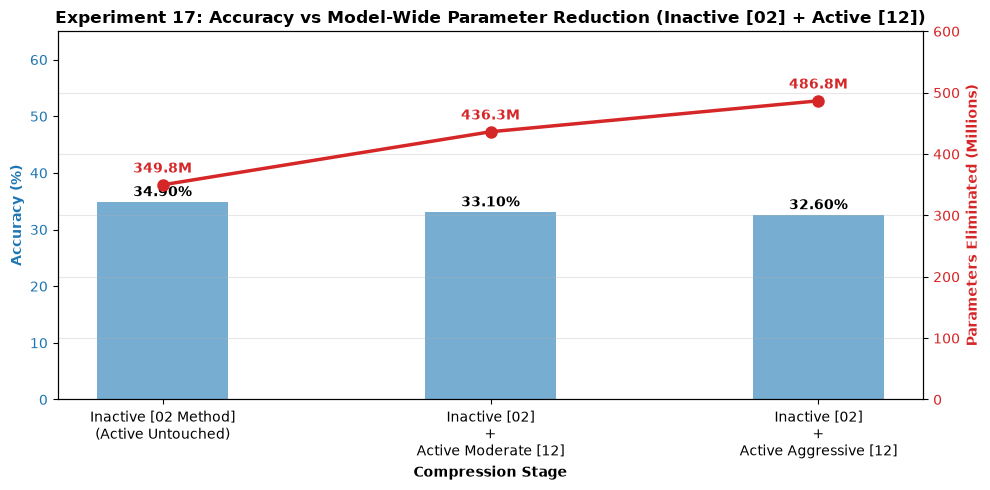


Saved Experiment 17 benchmark results to /home/dwithun/Development/llm_compression/experiments/02_all_layers_bench/artifacts/17_inactive_02_active_12_results.json
time: 0.25s
cummulative_time: 224.57s


In [8]:
# =====================================================================
# STEP 8: Comprehensive Side-by-Side Summary & Results Export
# =====================================================================
results_table = [
    {
        "variant": "Inactive [02 Method] (Active Untouched)",
        "inactive_method": "4D Tucker [30, 45, 16, 32]",
        "active_method": "Pristine FP32",
        "params_cut": inact_params_cut,
        "mlp_cut_pct": (inact_params_cut / (NUM_LAYERS * 3 * HIDDEN_DIM * INTERMEDIATE_DIM)) * 100,
        "accuracy": inact_02_accuracy,
        "recipe_snippet": inact_02_recipe[:100].replace("\n", " "),
    },
    {
        "variant": "Inactive [02] + Active Moderate [12]",
        "inactive_method": "4D Tucker [30, 45, 16, 32]",
        "active_method": "3D DBSCAN [4, 180, 600]",
        "params_cut": total_params_cut_moderate,
        "mlp_cut_pct": (total_params_cut_moderate / (NUM_LAYERS * 3 * HIDDEN_DIM * INTERMEDIATE_DIM)) * 100,
        "accuracy": moderate_accuracy,
        "recipe_snippet": moderate_recipe[:100].replace("\n", " "),
    },
    {
        "variant": "Inactive [02] + Active Aggressive [12]",
        "inactive_method": "4D Tucker [30, 45, 16, 32]",
        "active_method": "3D DBSCAN [3, 100, 350]",
        "params_cut": total_params_cut_aggressive,
        "mlp_cut_pct": (total_params_cut_aggressive / (NUM_LAYERS * 3 * HIDDEN_DIM * INTERMEDIATE_DIM)) * 100,
        "accuracy": aggressive_accuracy,
        "recipe_snippet": aggressive_recipe[:100].replace("\n", " "),
    },
]

print("=" * 120)
print(f"{'Configuration':<45} | {'Params Cut':<12} | {'MLP Cut %':<10} | {'Accuracy':<10} | {'Recipe Excerpt':<35}")
print("=" * 120)
for r in results_table:
    print(
        f"{r['variant']:<45} | "
        f"{r['params_cut']:<12,d} | "
        f"{r['mlp_cut_pct']:>8.1f}%  | "
        f"{r['accuracy'] * 100:>8.2f}% | "
        f"{r['recipe_snippet'][:35]}..."
    )
print("=" * 120)

# Plot Results
variants = [r["variant"].replace(" + ", "\n+\n").replace(" (", "\n(") for r in results_table]
accs = [r["accuracy"] * 100 for r in results_table]
cuts = [r["params_cut"] / 1e6 for r in results_table]

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Compression Stage', fontweight='bold')
ax1.set_ylabel('Accuracy (%)', color=color, fontweight='bold')
bars = ax1.bar(variants, accs, color=color, alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 65)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.0, f"{acc:.2f}%", ha='center', fontweight='bold')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Parameters Eliminated (Millions)', color=color, fontweight='bold')
ax2.plot(variants, cuts, color=color, marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 600)
for i, cut in enumerate(cuts):
    ax2.text(i, cut + 20, f"{cut:.1f}M", ha='center', color=color, fontweight='bold')

plt.title("Experiment 17: Accuracy vs Model-Wide Parameter Reduction (Inactive [02] + Active [12])", fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Export Results to JSON
artifacts_dir = repo_root / "experiments" / "02_all_layers_bench" / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)
results_file = artifacts_dir / "17_inactive_02_active_12_results.json"

payload = {
    "experiment": "17_gemma3_1b_it_inactive_02_active_12_tucker",
    "target_model": MODEL_ID,
    "num_layers": NUM_LAYERS,
    "num_projections": 78,
    "num_eval_samples": NUM_EVAL_SAMPLES,
    "recipe_query": CAKE_PROMPT,
    "results": results_table,
    "recipes": {
        "inactive_02": inact_02_recipe,
        "inactive_02_active_moderate_12": moderate_recipe,
        "inactive_02_active_aggressive_12": aggressive_recipe,
    }
}

with open(results_file, "w") as f:
    json.dump(payload, f, indent=2)

print(f"\nSaved Experiment 17 benchmark results to {results_file}")
